In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, accuracy_score, roc_auc_score
import numpy as np
from collections import Counter

In [30]:
class MicrobialInteractionDataset(Dataset):
    def __init__(self, df, model_type="bpt_large", layer=-1):
        self.df = df.reset_index(drop=True)
        self.model_type = model_type
        self.embedding_cache = {}
        self.layer = layer

        self.unique_carbons = df['Carbon'].unique().tolist()
        self.carbon_to_id = {c: i for i, c in enumerate(self.unique_carbons)}

        unique_classes = sorted(df['Class'].unique())
        self.class_to_id = {c: i for i, c in enumerate(unique_classes)}

        self.n_environments = len(self.unique_carbons)

        # print(f"Dataset: {len(df)} samples, {self.n_environments} environments, {len(unique_classes)} classes")

    def _load_embedding(self, bug_id):
        if bug_id in self.embedding_cache:
            return self.embedding_cache[bug_id]
        path = f"/orange/juannanzhou/bacteria_genome/interaction_data_genome_embeddings_{self.model_type}/{bug_id}_blm_all_layers.pt"
        if self.model_type == 'esm':
            emb = torch.load(path).float()
        else:
            emb = torch.load(path).float()[self.layer]
        self.embedding_cache[bug_id] = emb
        return emb

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        proteins_A = self._load_embedding(row['Bug 1']).mean(0).float().cpu()
        proteins_B = self._load_embedding(row['Bug 2']).mean(0).float().cpu()
        pApB = proteins_A*proteins_B
        env_id = torch.tensor(self.carbon_to_id[row['Carbon']], dtype=torch.long)
        env_onehot = F.one_hot(env_id, num_classes=self.n_environments).float()
        pairwise = torch.cat([proteins_A, proteins_B, pApB, env_onehot], dim=0)

        interaction_type = torch.tensor(self.class_to_id[row['Class']], dtype=torch.long)
        interaction_strength = torch.tensor(row['Strength'], dtype=torch.float32)

        return {
            'pairwise': pairwise,
            'interaction_type': interaction_type,
            'interaction_strength': interaction_strength,
            'species':(row['Bug 1'], row['Bug 2'])
        }


In [67]:
from torch.utils.data import DataLoader
import torch

def collate_keep_tuples(batch):
    # batch is a list of dicts
    keys = batch[0].keys()
    collated = {}
    for key in keys:
        if key == 'species':
            # keep as list of tuples, not auto-converted lists
            collated[key] = [b[key] for b in batch]
        else:
            collated[key] = torch.utils.data.default_collate([b[key] for b in batch])
    return collated

def merge_dataset(dataset, batch_size=64, num_workers=0):
    """
    Merge all batches from MicrobialInteractionDataset into full X, y_type, y_strength.
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_keep_tuples)
    X_all, species_name, y_type_all, y_strength_all = [], [], [], []

    for batch in loader:
        X_all.append(batch['pairwise'])
        species_name.extend(batch['species'])
        y_type_all.append(batch['interaction_type'])
        y_strength_all.append(batch['interaction_strength'])

    X = torch.cat(X_all, dim=0)
    y_type = torch.cat(y_type_all, dim=0)
    y_strength = torch.cat(y_strength_all, dim=0)

    return X, species_name, y_type, y_strength


def filter_rare_classes(X, species_name, y, k):
    if torch.is_tensor(y):
        y = y.cpu().tolist()

    counts = Counter(y)
    keep = [cls for cls, c in counts.items() if c >= k]
    mask = np.isin(y, keep)

    if torch.is_tensor(X):
        X = X[mask]
        y = torch.tensor(np.array(y)[mask])
    else:
        X, y = X[mask], np.array(y)[mask]

    species_name = [s for s, m in zip(species_name, mask) if m]
    new_counts = Counter(y.tolist() if torch.is_tensor(y) else y)
    assert X.shape[0] == len(species_name), f"problem with species sampling {X.shape[0]}, {len(species_name[0])}, {type(species_name)}, {species_name}"

    return X, species_name, y

def logistic_regression_cv(X, y, Cs=np.logspace(-3, 3, 10), k=5, max_iter=5000, seed=42):
    model = LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=max_iter
    )
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)
    # cv = StratifiedShuffleSplit(n_splits=k, random_state=seed)
    grid = GridSearchCV(model, {'C': Cs}, scoring='f1_macro', cv=cv, n_jobs=-1, refit=True)
    grid.fit(X, y)

    best_model = grid.best_estimator_
    best_C = grid.best_params_['C']

    # manual metrics on each fold
    f1s, accs, aucs = [], [], []
    for train_idx, val_idx in tqdm(cv.split(X, y), desc=f'{k} fold CV', leave=False):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        m = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs',
                               max_iter=max_iter)
        m.fit(X_train, y_train)

        y_pred = m.predict(X_val)
        y_proba = m.predict_proba(X_val)

        f1s.append(f1_score(y_val, y_pred, average='macro'))
    # print(f1s)
    metrics = {
        'F1': np.mean(f1s)
    }
    return best_model, best_C, metrics

import random
from collections import Counter

def species_disjoint_logistic_regression_cv(
    X, species_name, y, Cs=np.logspace(-3, 3, 10),
    k=3, max_iter=5000, seed=42, max_tries=300, env=None
):
    """
    Species-disjoint 80-20 train-validation split with multiple random splits.
    Generates k different train-val splits and returns mean F1.
    Ensures all classes appear in both train and validation sets for each split.
    """
    from sklearn.model_selection import StratifiedKFold
    from collections import Counter
    
    rng = np.random.default_rng(seed)
    random.seed(seed)
    if torch.is_tensor(y): y = y.cpu().numpy()
    if torch.is_tensor(X): X = X.cpu().numpy()
    all_classes = set(np.unique(y))
    all_species = sorted({s for pair in species_name for s in pair})
    
    f1s = []
    
    # Generate k different train-val splits
    for split_num in range(k):
        # Try multiple random species splits until valid
        for attempt in range(max_tries):
            rng.shuffle(all_species)
            
            # Split species 80-20
            split_idx = int(len(all_species) * 0.8)
            train_species = set(all_species[:split_idx])
            val_species = set(all_species[split_idx:])
            
            # Create train/val masks based on species
            train_mask = [
                (a in train_species and b in train_species)
                for (a, b) in species_name
            ]
            val_mask = [
                (a in val_species or b in val_species)
                for (a, b) in species_name
            ]
            
            train_idx = np.where(train_mask)[0]
            val_idx = np.where(val_mask)[0]
            
            # Check validity
            if len(train_idx) == 0 or len(val_idx) == 0:
                continue
            
            train_classes = set(np.unique(y[train_idx]))
            val_classes = set(np.unique(y[val_idx]))
            
            # Ensure all classes present in both train and val
            if all_classes.issubset(train_classes) and all_classes.issubset(val_classes):
                break
        else:
            raise RuntimeError(f"❌ Could not find valid species-disjoint split {split_num+1}/{k} after {max_tries} tries for {env}")
        
        # Train with the valid split
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Determine appropriate number of CV folds based on class distribution
        train_class_counts = Counter(y_train)
        min_class_count = min(train_class_counts.values())
        
        # Use fewer folds if classes are underrepresented
        if min_class_count < 3:
            inner_cv = min(2, min_class_count)  # Use 2-fold or even just train/val
        else:
            inner_cv = 3
        
        # Inner CV for best C
        model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=max_iter)
        
        if inner_cv >= 2:
            cv_splitter = StratifiedKFold(n_splits=inner_cv, shuffle=True, random_state=seed + split_num)
            grid = GridSearchCV(model, {'C': Cs}, scoring='f1_macro', cv=cv_splitter, n_jobs=-1, refit=True)
            grid.fit(X_train, y_train)
            best_C = grid.best_params_['C']
        else:
            # If we can't do CV, just try all Cs on a simple train/val split
            best_f1 = -1
            best_C = Cs[len(Cs)//2]  # default to middle C
            split_point = int(len(X_train) * 0.8)
            X_inner_train, X_inner_val = X_train[:split_point], X_train[split_point:]
            y_inner_train, y_inner_val = y_train[:split_point], y_train[split_point:]
            
            for C in Cs:
                m_temp = LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=max_iter)
                m_temp.fit(X_inner_train, y_inner_train)
                y_inner_pred = m_temp.predict(X_inner_val)
                f1_temp = f1_score(y_inner_val, y_inner_pred, average='macro')
                if f1_temp > best_f1:
                    best_f1 = f1_temp
                    best_C = C
        
        # Train final model with best C
        m = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', max_iter=max_iter)
        m.fit(X_train, y_train)
        y_pred = m.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='macro')
        f1s.append(f1)
    
    metrics = {'F1': np.mean(f1s)}
    return None, None, metrics

In [77]:
from tqdm.notebook import tqdm
import pandas as pd
import pickle
import random

def get_num_layers(emb_type):
    if emb_type == 'bpt_large':
        return 20
    if emb_type == 'bpt_small':
        return 11
    if emb_type == 'esm':
        return 1

df = pd.read_csv("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/species_interaction/data/env_pairwise_data/idatas.csv")
k = 3
seeds = [42, 54, 23, 45, 578]
# structure: env_vs_f1[seed][model][env][layer] = F1
env_vs_f1 = {}

for seed in tqdm(seeds, desc="Seeds"):
    env_vs_f1[seed] = {'esm': {}, 'bpt_large': {}, 'bpt_small': {}}
    for model_type in tqdm(['esm', 'bpt_large', 'bpt_small'], desc=f"Models (seed={seed})", leave=False):
        for layer in tqdm(range(get_num_layers(model_type)), desc=f"Layers ({model_type})", leave=False):
            for env in tqdm(df.Carbon.unique(), desc="Environments", leave=False):
                try:
                    df_env = df[df.Carbon == env].copy()
                    df_env['pair'] = df_env.apply(lambda r: tuple(sorted([r['Bug 1'], r['Bug 2']])), axis=1)
                    df_env = df_env.drop_duplicates(subset=['pair', 'Carbon', 'Class', 'Strength']).drop(columns='pair')

                    dataset = MicrobialInteractionDataset(df_env, model_type=model_type, layer=layer)
                    X, species_name, y_type, y_strength = merge_dataset(dataset)
                    X, species_name, y_type = filter_rare_classes(X, species_name, y_type, k)
                    best_model, best_c, metrics = species_disjoint_logistic_regression_cv(X, species_name, y_type, k=k, seed=seed, env=env)

                    env_vs_f1[seed][model_type].setdefault(env, {})
                    env_vs_f1[seed][model_type][env][layer] = metrics['F1']
                except ValueError:
                    continue
                except RuntimeError as e:
                    print(f"RuntimeError: {e}")
                    continue

with open("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/species_interaction/results/disjoint_env_vs_f1_all_seeds.pkl", "wb") as f:
    pickle.dump(env_vs_f1, f)


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Models (seed=42):   0%|          | 0/3 [00:00<?, ?it/s]

Layers (esm):   0%|          | 0/1 [00:00<?, ?it/s]

Environments:   0%|          | 0/40 [00:00<?, ?it/s]

Layers (bpt_large):   0%|          | 0/20 [00:00<?, ?it/s]

...

Environments:   0%|          | 0/40 [00:00<?, ?it/s]

Environments:   0%|          | 0/40 [00:00<?, ?it/s]

Environments:   0%|          | 0/40 [00:00<?, ?it/s]

Environments:   0%|          | 0/40 [00:00<?, ?it/s]

Environments:   0%|          | 0/40 [00:00<?, ?it/s]

In [1]:
import pandas as pd
df = pd.read_csv("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/species_interaction/data/env_pairwise_data/idatas.csv")


In [ ]:
df.

In [70]:
# with open("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/species_interaction/results/seed42_disjoint_env_vs_f1_all_seeds.pkl", "wb") as f:
#     pickle.dump(env_vs_f1, f)

In [69]:
env_vs_f1

{42: {'esm': {'ArabinoseL': {0: 0.4874628639334522},
   'Xylose': {0: 0.2539842873176206},
   'Ribose': {0: 0.3346801346801347},
   'Rhamnose': {0: 0.2759259259259259},
   'Fructose': {0: 0.3713323713323713},
   'Galactose': {0: 0.44422398589065254},
   'Glucose': {0: 0.17939814814814814},
   'Glucose01': {0: 0.36301476301476304},
   'Mannose': {0: 0.41774891774891776},
   'GlcNAc': {0: 0.6437044437044436},
   'Acetate': {0: 0.2285601109130521},
   'Pyruvate': {0: 0.5416666666666666},
   'Pyruvate01': {0: 0.6351540616246498},
   'Fumarate': {0: 0.20491452991452988},
   'Succinate': {0: 0.22033670033670036},
   'Citrate': {0: 0.6965990028490028},
   'Glycerol': {0: 0.3197789864456531},
   'Glycerol01': {0: 0.6423071567808409},
   'Mannitol': {0: 0.691919191919192},
   'Sorbitol': {0: 0.46448412698412705},
   'Alanine': {0: 0.22943469785575046},
   'Serine': {0: 0.09888888888888887},
   'Proline': {0: 0.3933333333333333},
   'Proline01': {0: 0.12130718954248365},
   'Glutamine': {0: 0.12

In [37]:
len(species_name)

26

In [38]:
X.shape

torch.Size([26, 1441])

In [7]:
env_vs_f1

{42: {'esm': {'ArabinoseL': {0: 0.8469604469604469},
   'Xylose': {0: 0.41615791615791614},
   'Ribose': {0: 0.5463351463351463},
   'Rhamnose': {0: 0.3466490299823633},
   'Fructose': {0: 0.3498677248677249},
   'Galactose': {0: 0.6801146384479718},
   'Glucose': {0: 0.3055555555555555},
   'Glucose01': {0: 0.4448292448292448},
   'Mannose': {0: 0.5155270655270655},
   'GlcNAc': {0: 0.8036556036556036},
   'Acetate': {0: 0.44166666666666665},
   'Pyruvate': {0: 0.7641554867561059},
   'Pyruvate01': {0: 0.720899470899471},
   'Fumarate': {0: 0.5448148148148148},
   'Succinate': {0: 0.3433333333333333},
   'Citrate': {0: 0.5554584304584305},
   'Glycerol': {0: 0.46560846560846564},
   'Glycerol01': {0: 0.691468253968254},
   'Mannitol': {0: 0.6444444444444445},
   'Sorbitol': {0: 0.40295815295815296},
   'Alanine': {0: 0.2891975308641976},
   'Serine': {0: 0.34435786435786425},
   'Proline': {0: 0.43851851851851853},
   'Proline01': {0: 0.3522222222222222},
   'Glutamine': {0: 0.3064814

In [78]:
import pickle
import numpy as np
import pandas as pd

with open("env_vs_f1_all_seeds.pkl", "rb") as f:
    env_vs_f1 = pickle.load(f)

models = ['esm', 'bpt_large', 'bpt_small']

all_envs = sorted({
    env
    for seed in env_vs_f1
    for model in models
    for env in env_vs_f1[seed][model].keys()
})

rows = []
for model in models:
    for env in all_envs:
        per_seed_best = []
        for seed in env_vs_f1:
            layer_dict = env_vs_f1[seed][model].get(env, {})
            if not layer_dict:
                continue
            best_layer = max(layer_dict, key=layer_dict.get)
            per_seed_best.append(layer_dict[best_layer])
        if per_seed_best:
            mean_f1 = np.mean(per_seed_best)
            std_f1 = np.std(per_seed_best)
            rows.append([model, env, mean_f1, std_f1])

df_summary = pd.DataFrame(rows, columns=['Model', 'Environment', 'Mean_F1', 'Std_F1'])
df_summary = df_summary.sort_values(['Environment', 'Model']).reset_index(drop=True)
print(df_summary)

df_summary.to_csv("disjoint_env_best_layer_mean_std.csv", index=False)


         Model Environment   Mean_F1    Std_F1
0    bpt_large     Acetate  0.297339  0.054108
1    bpt_small     Acetate  0.318435  0.084738
2          esm     Acetate  0.275689  0.078660
3    bpt_large     Alanine  0.314122  0.032696
4    bpt_small     Alanine  0.252958  0.013241
..         ...         ...       ...       ...
106  bpt_small     Uridine  0.486049  0.059602
107        esm     Uridine  0.451350  0.075685
108  bpt_large      Xylose  0.426531  0.027935
109  bpt_small      Xylose  0.321260  0.061926
110        esm      Xylose  0.257025  0.045509

[111 rows x 4 columns]


In [2]:
import pickle
import numpy as np
import pandas as pd
df_summary = pd.read_csv("/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/species_interaction/results/disjoint_env_best_layer_mean_std.csv")
print(df_summary)

         Model Environment   Mean_F1    Std_F1
0    bpt_large     Acetate  0.297339  0.054108
1    bpt_small     Acetate  0.318435  0.084738
2          esm     Acetate  0.275689  0.078660
3    bpt_large     Alanine  0.314122  0.032696
4    bpt_small     Alanine  0.252958  0.013241
..         ...         ...       ...       ...
106  bpt_small     Uridine  0.486049  0.059602
107        esm     Uridine  0.451350  0.075685
108  bpt_large      Xylose  0.426531  0.027935
109  bpt_small      Xylose  0.321260  0.061926
110        esm      Xylose  0.257025  0.045509

[111 rows x 4 columns]


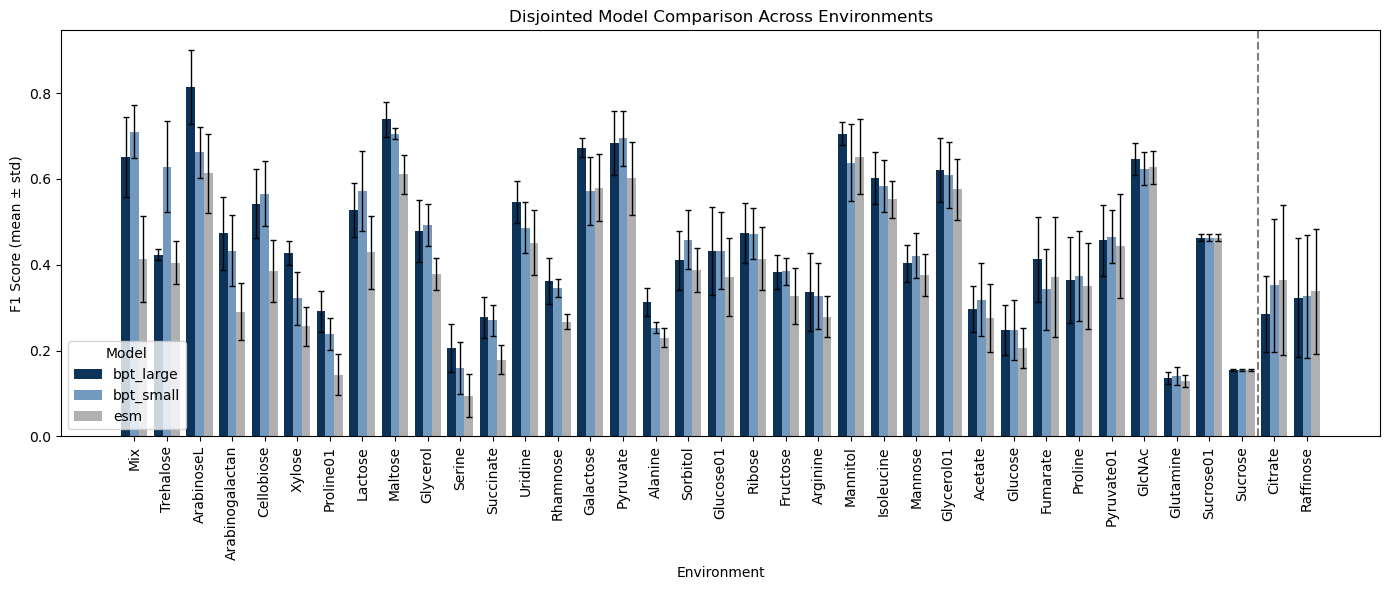

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- compute sort order by ΔF1 vs ESM ---
pivot = df_summary.pivot(index="Environment", columns="Model", values="Mean_F1")
pivot["Δ_large_esm"] = pivot["bpt_large"] - pivot["esm"]
pivot["Δ_small_esm"] = pivot["bpt_small"] - pivot["esm"]
pivot["max_Δ"] = pivot[["Δ_large_esm", "Δ_small_esm"]].max(axis=1)

# Sort environments by largest ΔF1
pivot_sorted = pivot.sort_values("max_Δ", ascending=False)
sorted_envs = pivot_sorted.index.tolist()
df_sorted = df_summary.copy()
df_sorted["Environment"] = pd.Categorical(df_sorted["Environment"], categories=sorted_envs, ordered=True)
df_sorted = df_sorted.sort_values(["Environment", "Model"])

# Define model order and colors
model_order = ["bpt_large", "bpt_small", "esm"]
palette = {"bpt_large": "#003366", "bpt_small": "#6699CC", "esm": "#B0B0B0"}

# --- find where esm starts to win ---
cross_idx = np.where(pivot_sorted["max_Δ"].values < 0)[0]
vline_pos = cross_idx[0] - 0.5 if len(cross_idx) > 0 else None

# --- plot ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=df_sorted,
    x="Environment",
    y="Mean_F1",
    hue="Model",
    hue_order=model_order,
    errorbar=None,
    palette=palette,
)

# add error bars properly
for i, model in enumerate(model_order):
    model_data = df_sorted[df_sorted["Model"] == model]
    container = ax.containers[i]
    xs = [bar.get_x() + bar.get_width() / 2 for bar in container]
    ax.errorbar(xs, model_data["Mean_F1"], yerr=model_data["Std_F1"],
                fmt="none", ecolor="black", elinewidth=1, capsize=2, zorder=3)

# draw vertical dashed line where esm overtakes
if vline_pos is not None:
    ax.axvline(x=vline_pos, color="grey", linestyle="--", linewidth=1.5)
    # plt.text(vline_pos + 0.3, 0.95, "ESM wins →", color="grey", fontsize=9, va="top")

plt.xticks(rotation=90)
plt.ylabel("F1 Score (mean ± std)")
plt.title("Disjointed Model Comparison Across Environments")
plt.legend(title="Model", loc="lower left")
plt.savefig('/blue/juannanzhou/palash.sethi/Projects/bacteria_genome/model_training/interpretation_tasks/results/figures/figures_v2/disjoint_sp_sp_int.png', dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


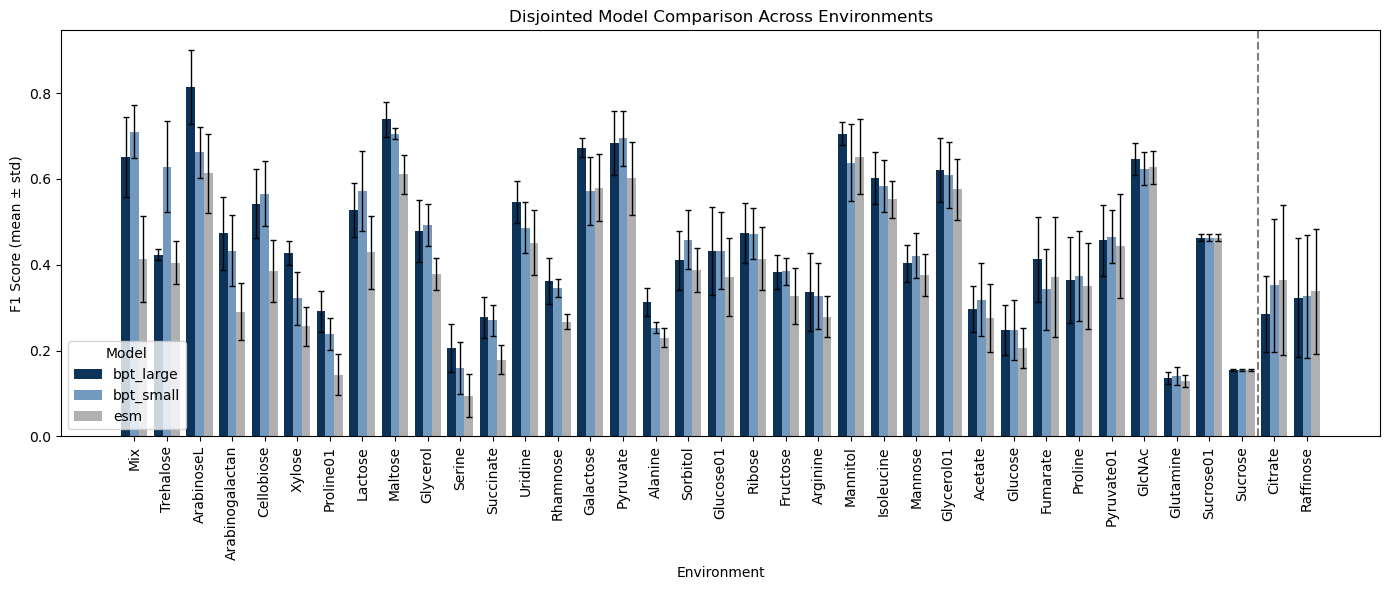

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- compute sort order by ΔF1 vs ESM ---
pivot = df_summary.pivot(index="Environment", columns="Model", values="Mean_F1")
pivot["Δ_large_esm"] = pivot["bpt_large"] - pivot["esm"]
pivot["Δ_small_esm"] = pivot["bpt_small"] - pivot["esm"]
pivot["max_Δ"] = pivot[["Δ_large_esm", "Δ_small_esm"]].max(axis=1)

# Sort environments by largest ΔF1
pivot_sorted = pivot.sort_values("max_Δ", ascending=False)
sorted_envs = pivot_sorted.index.tolist()
df_sorted = df_summary.copy()
df_sorted["Environment"] = pd.Categorical(df_sorted["Environment"], categories=sorted_envs, ordered=True)
df_sorted = df_sorted.sort_values(["Environment", "Model"])

# Define model order and colors
model_order = ["bpt_large", "bpt_small", "esm"]
palette = {"bpt_large": "#003366", "bpt_small": "#6699CC", "esm": "#B0B0B0"}

# --- find where esm starts to win ---
cross_idx = np.where(pivot_sorted["max_Δ"].values < 0)[0]
vline_pos = cross_idx[0] - 0.5 if len(cross_idx) > 0 else None

# --- plot ---
plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=df_sorted,
    x="Environment",
    y="Mean_F1",
    hue="Model",
    hue_order=model_order,
    errorbar=None,
    palette=palette,
)

# add error bars properly
for i, model in enumerate(model_order):
    model_data = df_sorted[df_sorted["Model"] == model]
    container = ax.containers[i]
    xs = [bar.get_x() + bar.get_width() / 2 for bar in container]
    ax.errorbar(xs, model_data["Mean_F1"], yerr=model_data["Std_F1"],
                fmt="none", ecolor="black", elinewidth=1, capsize=2, zorder=3)

# draw vertical dashed line where esm overtakes
if vline_pos is not None:
    ax.axvline(x=vline_pos, color="grey", linestyle="--", linewidth=1.5)
    # plt.text(vline_pos + 0.3, 0.95, "ESM wins →", color="grey", fontsize=9, va="top")

plt.xticks(rotation=90)
plt.ylabel("F1 Score (mean ± std)")
plt.title("Disjointed Model Comparison Across Environments")
plt.legend(title="Model", loc="lower left")
plt.tight_layout()
plt.show()


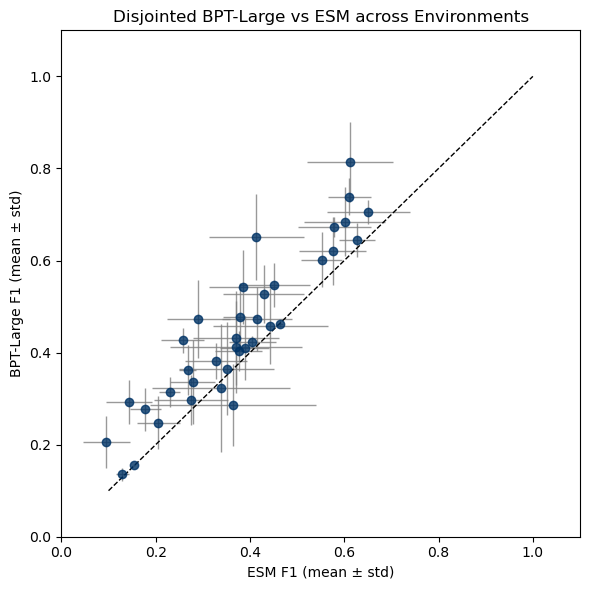

In [88]:
# Keep only bpt_large and esm
df_filtered = df_summary[df_summary["Model"].isin(["bpt_large", "esm"])]

# Pivot for scatter comparison
pivot = df_filtered.pivot(index="Environment", columns="Model", values=["Mean_F1", "Std_F1"])
pivot = pivot.dropna()

# Extract values
x = pivot["Mean_F1"]["esm"]
y = pivot["Mean_F1"]["bpt_large"]
xerr = pivot["Std_F1"]["esm"]
yerr = pivot["Std_F1"]["bpt_large"]

# Scatter plot with error bars
plt.figure(figsize=(6, 6))
plt.errorbar(
    x, y,
    xerr=xerr, yerr=yerr,
    fmt='o', ecolor='gray', capsize=0, elinewidth=1, alpha=0.8,
    color="#003366"
)

# Reference line y=x
plt.xlim(0,1.1)
plt.ylim(0,1.1)
plt.plot([0.1, 1], [0.1, 1], 'k--', linewidth=1)

plt.xlabel("ESM F1 (mean ± std)")
plt.ylabel("BPT-Large F1 (mean ± std)")
plt.title("Disjointed BPT-Large vs ESM across Environments")
plt.tight_layout()
plt.show()
